In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hourly-energy-consumption/est_hourly.paruqet
/kaggle/input/hourly-energy-consumption/DOM_hourly.csv
/kaggle/input/hourly-energy-consumption/EKPC_hourly.csv
/kaggle/input/hourly-energy-consumption/DUQ_hourly.csv
/kaggle/input/hourly-energy-consumption/DAYTON_hourly.csv
/kaggle/input/hourly-energy-consumption/PJME_hourly.csv
/kaggle/input/hourly-energy-consumption/PJM_Load_hourly.csv
/kaggle/input/hourly-energy-consumption/NI_hourly.csv
/kaggle/input/hourly-energy-consumption/FE_hourly.csv
/kaggle/input/hourly-energy-consumption/COMED_hourly.csv
/kaggle/input/hourly-energy-consumption/AEP_hourly.csv
/kaggle/input/hourly-energy-consumption/pjm_hourly_est.csv
/kaggle/input/hourly-energy-consumption/DEOK_hourly.csv
/kaggle/input/hourly-energy-consumption/PJMW_hourly.csv


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
import yaml
from torch.utils.data import DataLoader,TensorDataset,Dataset
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
color_pal=sns.color_palette()
plt.style.use('fivethirtyeight')

In [3]:
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# The dataset

**We create features that show previous energy consumption durin the week (7 days). Then we transform the dataset into a numpy matrix so we can standarizate and then convert it into a tensor before creating time series dataset for pytorch lstm model**

In [4]:
df=pd.read_csv("/kaggle/input/hourly-energy-consumption/PJME_hourly.csv")
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [5]:
def prepare_dataset(df,n_steps):
    df=df.copy()
    df=df.set_index('Datetime')
    df.index=pd.to_datetime(df.index)
    df = df.sort_index()
    for i in range(1,n_steps+1):
        df[f'PJME_MW(t-{i})']=df['PJME_MW'].shift(i)
    df.dropna(inplace=True)
    return df
    
    
n_steps=7
shifted_df=prepare_dataset(df,n_steps)
shifted_df.head()

,PJME_MW,PJME_MW(t-1),PJME_MW(t-2),PJME_MW(t-3),PJME_MW(t-4),PJME_MW(t-5),PJME_MW(t-6),PJME_MW(t-7)
Datetime,,,,,,,,
2002-01-01 08:00:00,29595.0,29308.0,28654.0,28057.0,27899.0,28357.0,29265.0,30393.0
2002-01-01 09:00:00,29943.0,29595.0,29308.0,28654.0,28057.0,27899.0,28357.0,29265.0
2002-01-01 10:00:00,30692.0,29943.0,29595.0,29308.0,28654.0,28057.0,27899.0,28357.0
2002-01-01 11:00:00,31395.0,30692.0,29943.0,29595.0,29308.0,28654.0,28057.0,27899.0
2002-01-01 12:00:00,31496.0,31395.0,30692.0,29943.0,29595.0,29308.0,28654.0,28057.0


<Axes: title={'center': 'PJME Energy Consumption in MW'}, xlabel='Datetime'>

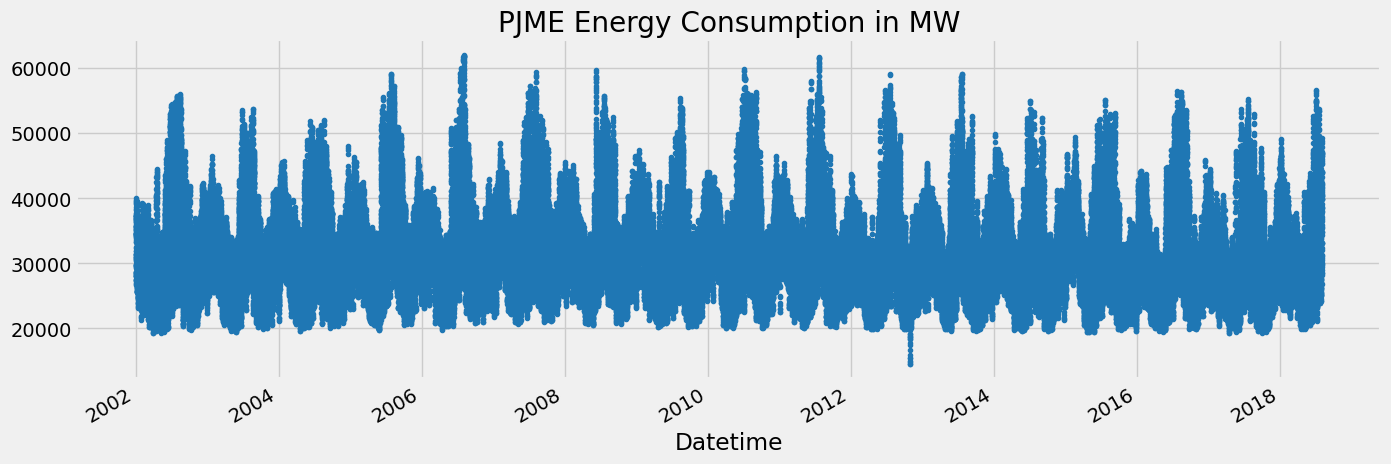

In [6]:
shifted_df['PJME_MW'].plot(style='.',figsize=(15,5),color=color_pal[0],title='PJME Energy Consumption in MW')

In [7]:
shifted_df_np=shifted_df.to_numpy()
shifted_df_np

array([[29595., 29308., 28654., ..., 28357., 29265., 30393.],
       [29943., 29595., 29308., ..., 27899., 28357., 29265.],
       [30692., 29943., 29595., ..., 28057., 27899., 28357.],
       ...,
       [41552., 43256., 44057., ..., 46816., 46989., 47154.],
       [38500., 41552., 43256., ..., 46760., 46816., 46989.],
       [35486., 38500., 41552., ..., 45641., 46760., 46816.]])

In [8]:
scaler=MinMaxScaler(feature_range=(-1,1))
shifted_df_np=scaler.fit_transform(shifted_df_np)
shifted_df_np

array([[-0.36580638, -0.3778995 , -0.40545665, ..., -0.41797114,
        -0.37971137, -0.33218161],
       [-0.35114295, -0.36580638, -0.3778995 , ..., -0.43726957,
        -0.41797114, -0.37971137],
       [-0.31958285, -0.35114295, -0.36580638, ..., -0.43061203,
        -0.43726957, -0.41797114],
       ...,
       [ 0.13801749,  0.20981776,  0.24356895, ...,  0.35982303,
         0.36711261,  0.3740651 ],
       [ 0.00941747,  0.13801749,  0.20981776, ...,  0.35746339,
         0.35982303,  0.36711261],
       [-0.11758138,  0.00941747,  0.13801749, ...,  0.31031286,
         0.35746339,  0.35982303]])

In [9]:
X=shifted_df_np[:,1:]
y=shifted_df_np[:,0]
print(f"Shape of X is {X.shape}, and the shape of y is {y.shape}")

Shape of X is (145359, 7), and the shape of y is (145359,)


In [10]:
X=X.copy()
X=np.flip(X,axis=1)
X

array([[-0.33218161, -0.37971137, -0.41797114, ..., -0.43061203,
        -0.40545665, -0.3778995 ],
       [-0.37971137, -0.41797114, -0.43726957, ..., -0.40545665,
        -0.3778995 , -0.36580638],
       [-0.41797114, -0.43726957, -0.43061203, ..., -0.3778995 ,
        -0.36580638, -0.35114295],
       ...,
       [ 0.3740651 ,  0.36711261,  0.35982303, ...,  0.31031286,
         0.24356895,  0.20981776],
       [ 0.36711261,  0.35982303,  0.35746339, ...,  0.24356895,
         0.20981776,  0.13801749],
       [ 0.35982303,  0.35746339,  0.31031286, ...,  0.20981776,
         0.13801749,  0.00941747]])

In [11]:
split_index=int(len(shifted_df_np)*0.8)
split_index

116287

In [12]:
X_train=X[:split_index]
X_test=X[split_index:]
y_train=y[:split_index]
y_test=y[split_index:]
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((116287, 7), (29072, 7), (116287,), (29072,))

In [13]:
X_train=X_train.reshape((-1,n_steps,1))
X_test=X_test.reshape((-1,n_steps,1))
y_train=y_train.reshape((-1,1))
y_test=y_test.reshape((-1,1))
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((116287, 7, 1), (29072, 7, 1), (116287, 1), (29072, 1))

In [14]:
X_train=torch.tensor(X_train.copy()).float()
X_test=torch.tensor(X_test.copy()).float()
y_train=torch.tensor(y_train.copy()).float()
y_test=torch.tensor(y_test.copy()).float()

X_train.shape,X_test.shape,y_train.shape,y_test.shape

(torch.Size([116287, 7, 1]),
 torch.Size([29072, 7, 1]),
 torch.Size([116287, 1]),
 torch.Size([29072, 1]))

In [15]:
class TimeSeriesDataset(Dataset):
    """
    Rather than raw tensors we use actually custom datasets in Pytorch
    """
    def __init__(self,X,y):
        self.X=X
        self.y=y
    def __len__(self):
        return len(self.X)
    def __getitem__(self,i):
        return self.X[i],self.y[i]

train_dataset=TimeSeriesDataset(X_train,y_train)
test_dataset=TimeSeriesDataset(X_test,y_test)

In [16]:
train_dataset

In [17]:
batch_size=32
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [18]:
for _,batch in enumerate(train_loader):
    x_batch,y_batch=batch[0].to(device),batch[1].to(device)
    print(x_batch.shape,y_batch.shape)
    break

torch.Size([32, 7, 1]) torch.Size([32, 1])


# The LSTM model
**Pytorch has a defined lstm function within the *torch.nn***

In [19]:
class LSTM(nn.Module):
    def __init__(self,input_size,hidden_size,num_stacked_layer):
        #The more you have of stacked layer the more the model is complex
        # AKA: as lstm run throught themselve they are going to recurse and create sequence throught themselves so you can stack these yourself by num_stacked_layer
        super().__init__()
        self.hidden_size=hidden_size
        self.num_stacked_layer=num_stacked_layer
        self.lstm=nn.LSTM(input_size,hidden_size,num_stacked_layer,batch_first=True)
        self.fc=nn.Linear(hidden_size,1)
    def forward(self,x):
        batch_size=x.size(0)
        h0=torch.zeros(self.num_stacked_layer,batch_size,self.hidden_size).to(device)
        c0=torch.zeros(self.num_stacked_layer,batch_size,self.hidden_size).to(device)
        out,_=self.lstm(x,(h0,c0))
        out=self.fc(out[:,-1,:])
        return out


model = LSTM(1, 32, 1)
model.to(device)
model

LSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [20]:
learning_rate=1e-3
num_epochs=10

In [21]:
def train_one_epoch():
    model.train()
    print(f"Epoch {epoch+1}")
    running_loss=0.0
    for batch_idx,batch in enumerate(train_loader):
        x_batch,y_batch=batch[0].to(device),batch[1].to(device)
        optimizer.zero_grad()
        output=model(x_batch)
        loss=loss_function(output,y_batch)
        running_loss+=loss
        loss.backward()
        optimizer.step()

        if batch_idx%100==99:
            avg_loss=running_loss/100
            print(f'Batch {batch_idx+1}, Loss {avg_loss:0.3f}')
            running_loss=0
    print()

In [22]:
def eval_one_epoch():
    model.eval()
    running_loss=0.0
    for batch_idx,batch in enumerate(test_loader):
        x_batch,y_batch=batch[0].to(device),batch[1].to(device)
        with torch.no_grad():
            output=model(x_batch)
            loss=loss_function(y_batch,output)
            running_loss+=loss
    avg_loss=running_loss/len(test_loader)
    print(f'Val Loss {avg_loss:0.3f}')
    print('**************************************************')
    print()

In [23]:
loss_function=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=learning_rate,weight_decay=1e-4)
for epoch in range(num_epochs):
    train_one_epoch()
    eval_one_epoch()

Epoch 1
Batch 100, Loss 0.049
Batch 200, Loss 0.020
Batch 300, Loss 0.008
Batch 400, Loss 0.006
Batch 500, Loss 0.004
Batch 600, Loss 0.003
Batch 700, Loss 0.003
Batch 800, Loss 0.002
Batch 900, Loss 0.002
Batch 1000, Loss 0.002
Batch 1100, Loss 0.002
Batch 1200, Loss 0.002
Batch 1300, Loss 0.002
Batch 1400, Loss 0.002
Batch 1500, Loss 0.002
Batch 1600, Loss 0.002
Batch 1700, Loss 0.002
Batch 1800, Loss 0.002
Batch 1900, Loss 0.002
Batch 2000, Loss 0.002
Batch 2100, Loss 0.001
Batch 2200, Loss 0.001
Batch 2300, Loss 0.001
Batch 2400, Loss 0.001
Batch 2500, Loss 0.001
Batch 2600, Loss 0.001
Batch 2700, Loss 0.001
Batch 2800, Loss 0.001
Batch 2900, Loss 0.001
Batch 3000, Loss 0.001
Batch 3100, Loss 0.001
Batch 3200, Loss 0.001
Batch 3300, Loss 0.001
Batch 3400, Loss 0.001
Batch 3500, Loss 0.001
Batch 3600, Loss 0.001

Val Loss 0.001
**************************************************

Epoch 2
Batch 100, Loss 0.001
Batch 200, Loss 0.001
Batch 300, Loss 0.001
Batch 400, Loss 0.001
Batch 500

# Plots
## We plot train predictions vs actual train data

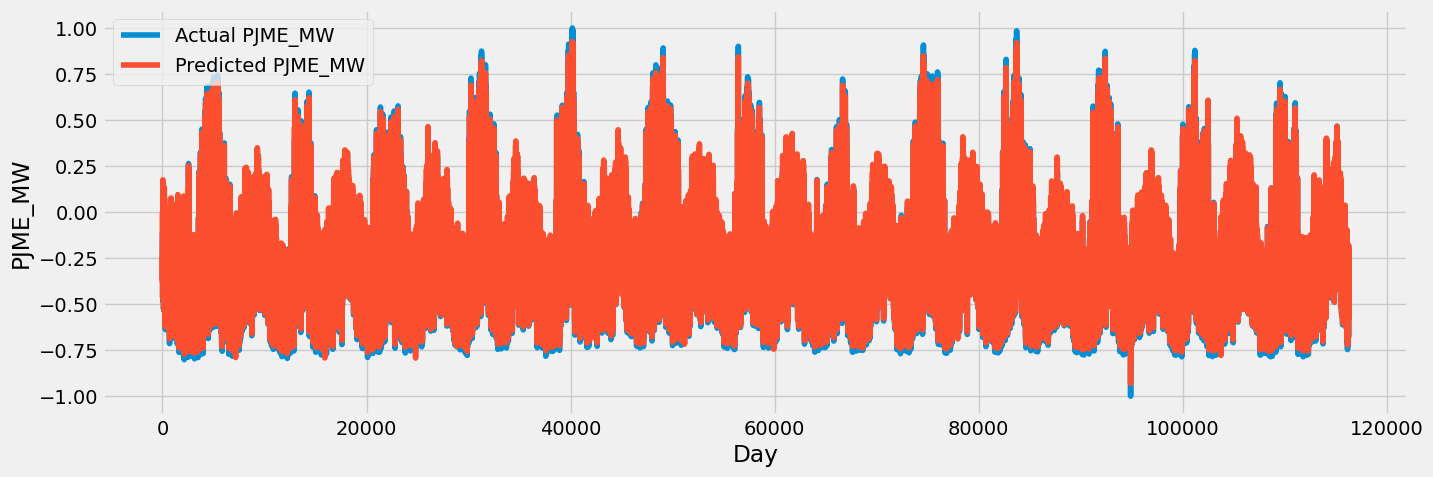

In [24]:
with torch.no_grad():
    predicted=model(X_train.to(device)).to('cpu').numpy()
    
plt.figure(figsize=(15,5))
plt.plot(y_train,label='Actual PJME_MW')
plt.plot(predicted,label='Predicted PJME_MW')
plt.xlabel('Day')
plt.ylabel('PJME_MW')
plt.legend()
plt.show()

**We get y axis between -1 and 1 which isn't actual values of energy**

In [25]:
train_predictions=predicted.flatten()
dummies=np.zeros((X_train.shape[0],n_steps+1))
dummies[:,0]=train_predictions
dummies=scaler.inverse_transform(dummies)

train_predictions=train_predictions.copy()
train_predictions=dummies[:,0]
train_predictions

array([29874.39218217, 29723.48332071, 30227.26022193, ...,
       32186.93588795, 32282.68582204, 31653.57897134])

In [26]:
dummies=np.zeros((X_train.shape[0],n_steps+1))
dummies[:,0]=y_train.flatten()
dummies=scaler.inverse_transform(dummies)


new_y_train=dummies[:,0]
new_y_train

/tmp/ipykernel_24/484892390.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  dummies[:,0]=y_train.flatten()


array([29595.00030087, 29943.0001075 , 30692.00001852, ...,
       32613.00000185, 32203.99981247, 32049.00002258])

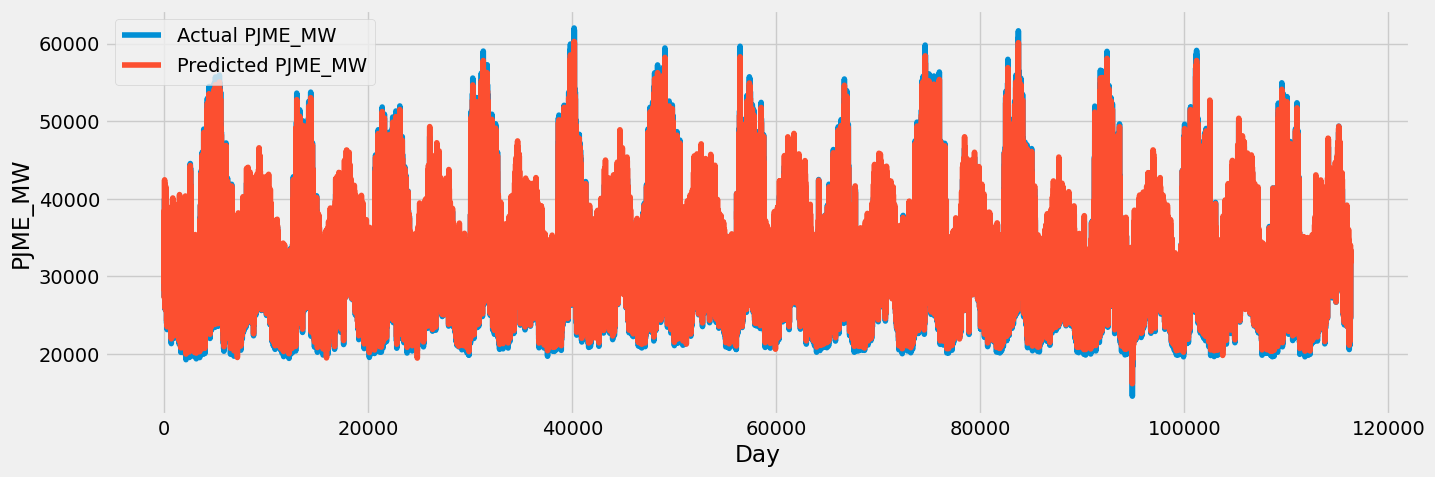

In [27]:
plt.figure(figsize=(15,5))
plt.plot(new_y_train,label='Actual PJME_MW')
plt.plot(train_predictions,label='Predicted PJME_MW')
plt.xlabel('Day')
plt.ylabel('PJME_MW')
plt.legend()
plt.show()

## We plot the comparaison between the test predictions and actual test data

In [28]:
test_predictions=model(X_test.to(device)).detach().cpu().numpy().flatten()
dummies=np.zeros((X_test.shape[0],n_steps+1))
dummies[:,0]=test_predictions
dummies=scaler.inverse_transform(dummies)

test_predictions=test_predictions.copy()
test_predictions=dummies[:,0]
test_predictions

array([31964.5425787 , 32231.94741727, 33119.72132476, ...,
       41984.33286203, 39197.19477703, 35292.9160125 ])

In [29]:
dummies=np.zeros((y_test.shape[0],n_steps+1))
dummies[:,0]=y_test.flatten()
dummies=scaler.inverse_transform(dummies)


new_y_test=dummies[:,0]
new_y_test

/tmp/ipykernel_24/2186469247.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  dummies[:,0]=y_test.flatten()


array([32209.00030763, 32707.00011627, 33011.99990818, ...,
       41552.00009344, 38500.00000919, 35486.00001916])

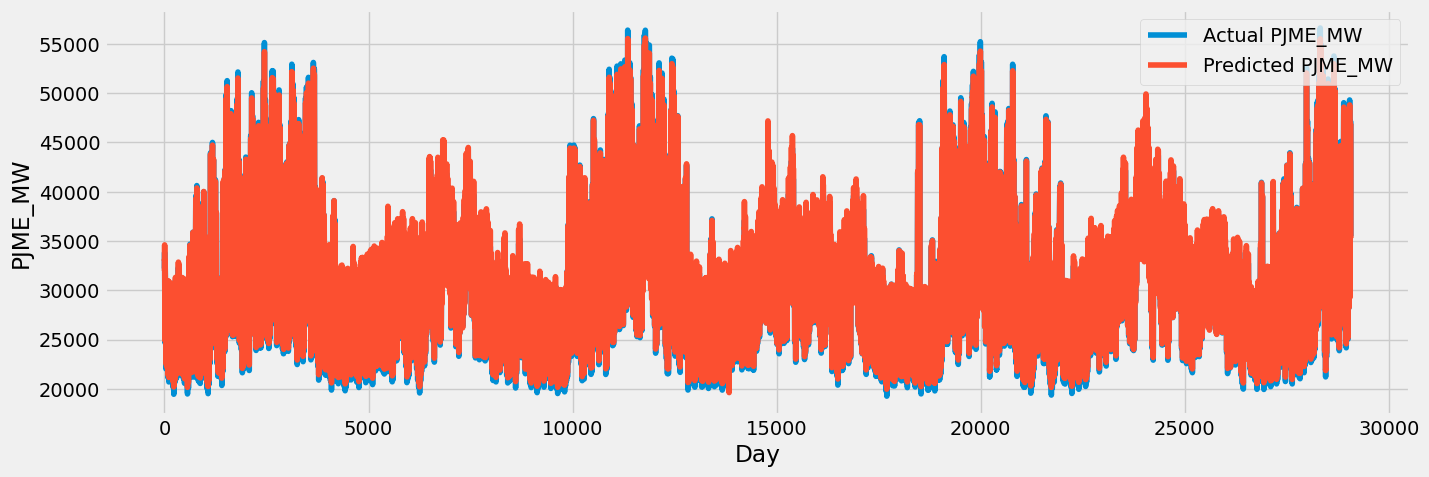

In [30]:
plt.figure(figsize=(15,5))
plt.plot(new_y_test,label='Actual PJME_MW')
plt.plot(test_predictions,label='Predicted PJME_MW')
plt.xlabel('Day')
plt.ylabel('PJME_MW')
plt.legend()
plt.show()

# *The end*